In [ ]:
!pip install numpy scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 28.5 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz

In [ ]:
# --- 1. Definisikan Variabel Semesta (Universe) ---
# Berdasarkan range yang diberikan di soal

# Suhu Tubuh (°C): 36 - 41 (ambil sedikit lebih lebar untuk plot)
x_suhu = np.arange(35, 42, 0.1)
# Trombosit (x10^9/L): <150 (Rendah) hingga 400 (Normal). Ambil 0-500
x_trombosit = np.arange(0, 500, 1)
# Leukosit (x10^9/L): <4 (Rendah) hingga 10 (Normal). Ambil 0-15
x_leukosit = np.arange(0, 15, 0.1)

# Output Risiko DBD (0-100)
x_risiko = np.arange(0, 101, 1)

In [ ]:
# --- 2. Definisikan Fungsi Keanggotaan (Membership Functions) Input ---

# Suhu Tubuh (°C)
# Normal: 36-37.5 [cite: 13] (Trapesium/Segitiga)
suhu_normal = fuzz.trimf(x_suhu, [36, 36.5, 37.5])
# Demam: 37-39 [cite: 14]
suhu_demam = fuzz.trimf(x_suhu, [37, 38, 39])
# Tinggi: 38-41 [cite: 16] (Trapesium/Segitiga)
suhu_tinggi = fuzz.trapmf(x_suhu, [38, 39, 41, 41]) # Diasumsikan 38-41

# Trombosit (x10^9/L)
# Rendah: < 150 [cite: 25] (Z-curve/Trapezoid)
trombosit_rendah = fuzz.trapmf(x_trombosit, [0, 0, 120, 150])
# Normal: 150-400 [cite: 26] (Segitiga)
trombosit_normal = fuzz.trimf(x_trombosit, [150, 275, 400])

# Leukosit (x10^9/L)
# Rendah: < 4 [cite: 23] (Z-curve/Trapezoid)
leukosit_rendah = fuzz.trapmf(x_leukosit, [0, 0, 3, 4])
# Normal: 4-10 [cite: 23] (Segitiga)
leukosit_normal = fuzz.trimf(x_leukosit, [4, 7, 10])

In [ ]:
# --- 3. Definisikan Fungsi Keanggotaan Output (Untuk Tsukamoto) ---
# Catatan: Fungsi ini digunakan untuk mencari nilai crisp (z_i)
# Rendah: 0-40[cite: 32]. Linear turun (1 di 0, 0 di 40)
def tsukamoto_rendah(alpha):
    # alpha = (40 - z) / 40  ==>  z = 40 - (alpha * 40)
    return 40 - (alpha * 40)

# Sedang: 30-70[cite: 34]. Asumsi Trapesium/Segitiga. Untuk Tsukamoto kita butuh fungsi invers.
# Asumsi kita gunakan fungsi invers linier naik/turun di batasnya.
# Untuk Sedang, kita asumsikan pada batas kiri (30-50) kita pakai fungsi naik, dan batas kanan (50-70) pakai fungsi turun.
# Kita akan gunakan fungsi invers linier naik dari 30 ke 50.
def tsukamoto_sedang_inv(alpha):
    # asumsikan Sedang naik dari 30 ke 50: alpha = (z - 30) / 20  ==> z = (alpha * 20) + 30
    return (alpha * 20) + 30

# Tinggi: 60-100[cite: 38]. Linear naik (0 di 60, 1 di 100)
def tsukamoto_tinggi(alpha):
    # alpha = (z - 60) / 40  ==>  z = (alpha * 40) + 60
    return (alpha * 40) + 60

In [ ]:
# --- 4. Nilai Input Pasien ---
# Suhu Tubuh = 38.5 °C [cite: 55]
# Trombosit = 120 x 10^9/L [cite: 56]
# Leukosit = 3.8 x 10^9/L [cite: 57]
suhu_in = 38.5
trombosit_in = 120
leukosit_in = 3.8

In [ ]:
# --- 5. Fuzzifikasi Input ---
mu_suhu = {}
mu_suhu['Normal'] = fuzz.interp_membership(x_suhu, suhu_normal, suhu_in)
mu_suhu['Demam'] = fuzz.interp_membership(x_suhu, suhu_demam, suhu_in)
mu_suhu['Tinggi'] = fuzz.interp_membership(x_suhu, suhu_tinggi, suhu_in)

mu_trombosit = {}
mu_trombosit['Rendah'] = fuzz.interp_membership(x_trombosit, trombosit_rendah, trombosit_in)
mu_trombosit['Normal'] = fuzz.interp_membership(x_trombosit, trombosit_normal, trombosit_in)

mu_leukosit = {}
mu_leukosit['Rendah'] = fuzz.interp_membership(x_leukosit, leukosit_rendah, leukosit_in)
mu_leukosit['Normal'] = fuzz.interp_membership(x_leukosit, leukosit_normal, leukosit_in)


print("="*50)
print("Fuzzifikasi Input:")
print(f"Suhu Tubuh (38.5): Normal={mu_suhu['Normal']:.3f}, Demam={mu_suhu['Demam']:.3f}, Tinggi={mu_suhu['Tinggi']:.3f}")
print(f"Trombosit (120): Rendah={mu_trombosit['Rendah']:.3f}, Normal={mu_trombosit['Normal']:.3f}")
print(f"Leukosit (3.8): Rendah={mu_leukosit['Rendah']:.3f}, Normal={mu_leukosit['Normal']:.3f}")
print("="*50)

Fuzzifikasi Input:
Suhu Tubuh (38.5): Normal=0.000, Demam=0.500, Tinggi=0.500
Trombosit (120): Rendah=1.000, Normal=0.000
Leukosit (3.8): Rendah=0.200, Normal=0.000


In [ ]:
# --- 6. Inferensi (Rule Evaluation) ---
# Menggunakan operator MIN (AND) [cite: 36]

# R1: Jika Suhu tinggi AND Trombosit rendah AND Leukosit rendah maka Risiko = Tinggi [cite: 39]
alpha1 = np.fmin.reduce([mu_suhu['Tinggi'], mu_trombosit['Rendah'], mu_leukosit['Rendah']])
z1 = tsukamoto_tinggi(alpha1)
print(f"Rule 1 (Tinggi, alpha={alpha1:.3f}): z = {z1:.2f}")

# R2: Jika Suhu demam AND Trombosit rendah maka Risiko = Tinggi [cite: 41]
alpha2 = np.fmin(mu_suhu['Demam'], mu_trombosit['Rendah'])
z2 = tsukamoto_tinggi(alpha2)
print(f"Rule 2 (Tinggi, alpha={alpha2:.3f}): z = {z2:.2f}")

# R3: Jika Suhu demam AND Trombosit normal maka Risiko = Sedang [cite: 43]
alpha3 = np.fmin(mu_suhu['Demam'], mu_trombosit['Normal'])
# Untuk z3, kita pakai Sedang. Kita asumsikan Sedang linier naik untuk batas kiri (30-70)
# Perhatian: Karena alpha3=0, nilai z3 tidak akan digunakan dalam rata-rata berbobot, jadi tidak perlu dihitung.
print(f"Rule 3 (Sedang, alpha={alpha3:.3f}): Tidak aktif")

# R4: Jika Suhu normal AND Trombosit normal AND Leukosit normal maka Risiko = Rendah [cite: 45]
alpha4 = np.fmin.reduce([mu_suhu['Normal'], mu_trombosit['Normal'], mu_leukosit['Normal']])
# Perhatian: alpha4=0.
print(f"Rule 4 (Rendah, alpha={alpha4:.3f}): Tidak aktif")

# R5: Jika Suhu tinggi AND Leukosit normal maka Risiko = Sedang [cite: 47]
alpha5 = np.fmin(mu_suhu['Tinggi'], mu_leukosit['Normal'])
# Perhatian: alpha5=0.
print(f"Rule 5 (Sedang, alpha={alpha5:.3f}): Tidak aktif")

Rule 1 (Tinggi, alpha=0.200): z = 68.00
Rule 2 (Tinggi, alpha=0.500): z = 80.00
Rule 3 (Sedang, alpha=0.000): Tidak aktif
Rule 4 (Rendah, alpha=0.000): Tidak aktif
Rule 5 (Sedang, alpha=0.000): Tidak aktif


In [ ]:
# --- 7. Defuzzifikasi (Weighted Average) ---
# Hanya rule yang aktif (alpha > 0) yang digunakan: R1 dan R2.

# Pembilang (Numerator): sum(alpha_i * z_i)
numerator = (alpha1 * z1) + (alpha2 * z2)

# Penyebut (Denominator): sum(alpha_i)
denominator = alpha1 + alpha2

# Hitung hasil defuzzifikasi
if denominator > 0:
    risiko_dbd = numerator / denominator
else:
    risiko_dbd = 0 # Kasus jika tidak ada rule yang aktif

print("="*50)
print(f"Total Pembilang (Σαz): {numerator:.3f}")
print(f"Total Penyebut (Σα): {denominator:.3f}")
print(f"Hasil Defuzzifikasi (Z*): {risiko_dbd:.2f}")

Total Pembilang (Σαz): 53.600
Total Penyebut (Σα): 0.700
Hasil Defuzzifikasi (Z*): 76.57


In [ ]:
# --- 8. Kesimpulan ---
if risiko_dbd <= 40:
    kesimpulan = "Rendah"
elif risiko_dbd <= 70:
    # Karena nilainya > 60, ini sudah masuk range Tinggi juga.
    # Kita ambil yang paling dominan di range 30-70
    kesimpulan = "Sedang/Tinggi"
elif risiko_dbd > 70:
    kesimpulan = "Tinggi"
else:
    kesimpulan = "Tidak terdefinisi"

print(f"\nDIAGNOSA AKHIR: Tingkat Risiko DBD = {kesimpulan} (Nilai Crisp: {risiko_dbd:.2f})")
print("="*65)


DIAGNOSA AKHIR: Tingkat Risiko DBD = Tinggi (Nilai Crisp: 76.57)


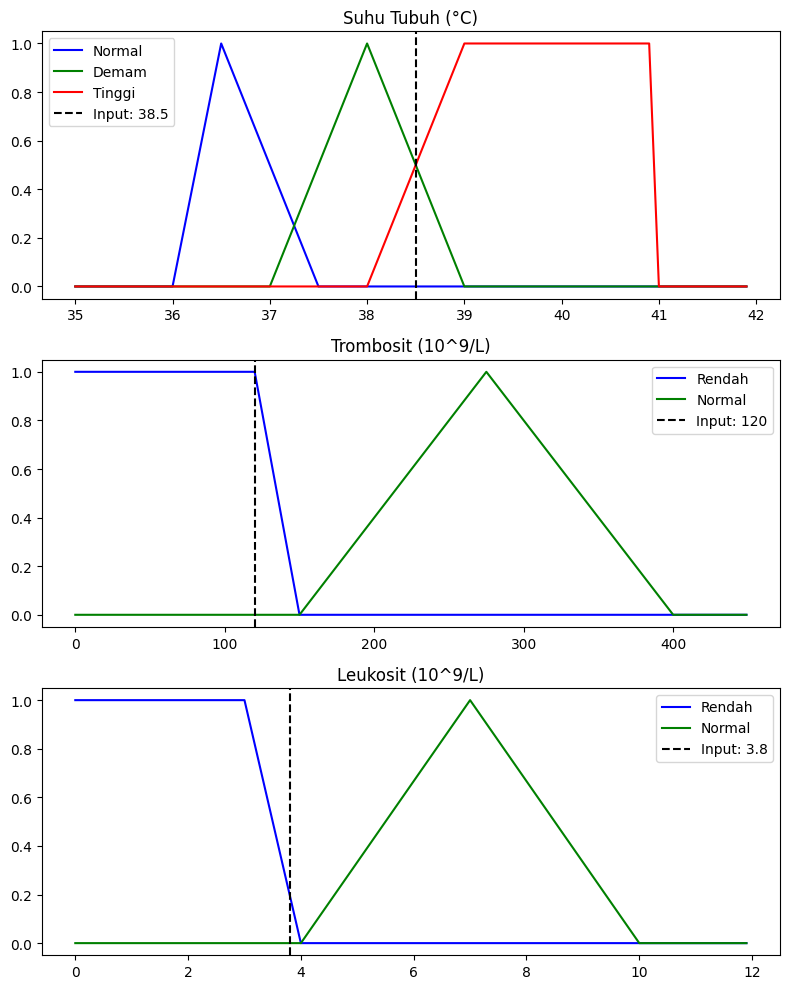

In [ ]:
# Range semesta
x_suhu = np.arange(35, 42, 0.1)
x_trombosit = np.arange(0, 450, 1)
x_leukosit = np.arange(0, 12, 0.1)

# Definisi Fungsi Keanggotaan
suhu_normal = fuzz.trimf(x_suhu, [36, 36.5, 37.5])
suhu_demam = fuzz.trimf(x_suhu, [37, 38, 39])
suhu_tinggi = fuzz.trapmf(x_suhu, [38, 39, 41, 41])

trombosit_rendah = fuzz.trapmf(x_trombosit, [0, 0, 120, 150])
trombosit_normal = fuzz.trimf(x_trombosit, [150, 275, 400])

leukosit_rendah = fuzz.trapmf(x_leukosit, [0, 0, 3, 4])
leukosit_normal = fuzz.trimf(x_leukosit, [4, 7, 10])

# Plotting
fig, (ax0, ax1, ax2) = plt.subplots(nrows=3, figsize=(8, 10))

ax0.plot(x_suhu, suhu_normal, 'b', label='Normal')
ax0.plot(x_suhu, suhu_demam, 'g', label='Demam')
ax0.plot(x_suhu, suhu_tinggi, 'r', label='Tinggi')
ax0.axvline(x=38.5, color='k', linestyle='--', label='Input: 38.5')
ax0.set_title('Suhu Tubuh (°C)')
ax0.legend()

ax1.plot(x_trombosit, trombosit_rendah, 'b', label='Rendah')
ax1.plot(x_trombosit, trombosit_normal, 'g', label='Normal')
ax1.axvline(x=120, color='k', linestyle='--', label='Input: 120')
ax1.set_title('Trombosit (10^9/L)')
ax1.legend()

ax2.plot(x_leukosit, leukosit_rendah, 'b', label='Rendah')
ax2.plot(x_leukosit, leukosit_normal, 'g', label='Normal')
ax2.axvline(x=3.8, color='k', linestyle='--', label='Input: 3.8')
ax2.set_title('Leukosit (10^9/L)')
ax2.legend()

plt.tight_layout()
plt.show()